<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias_comp_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
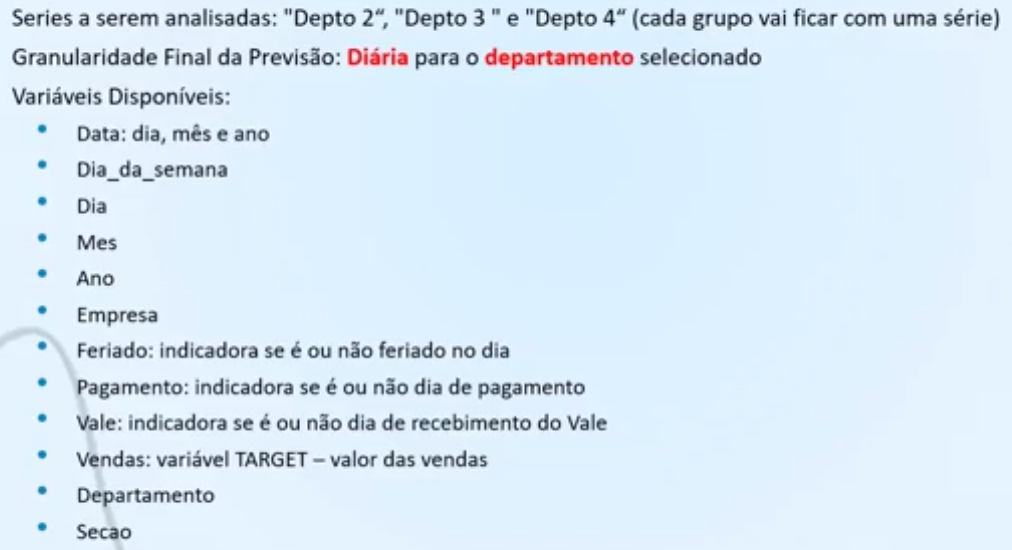

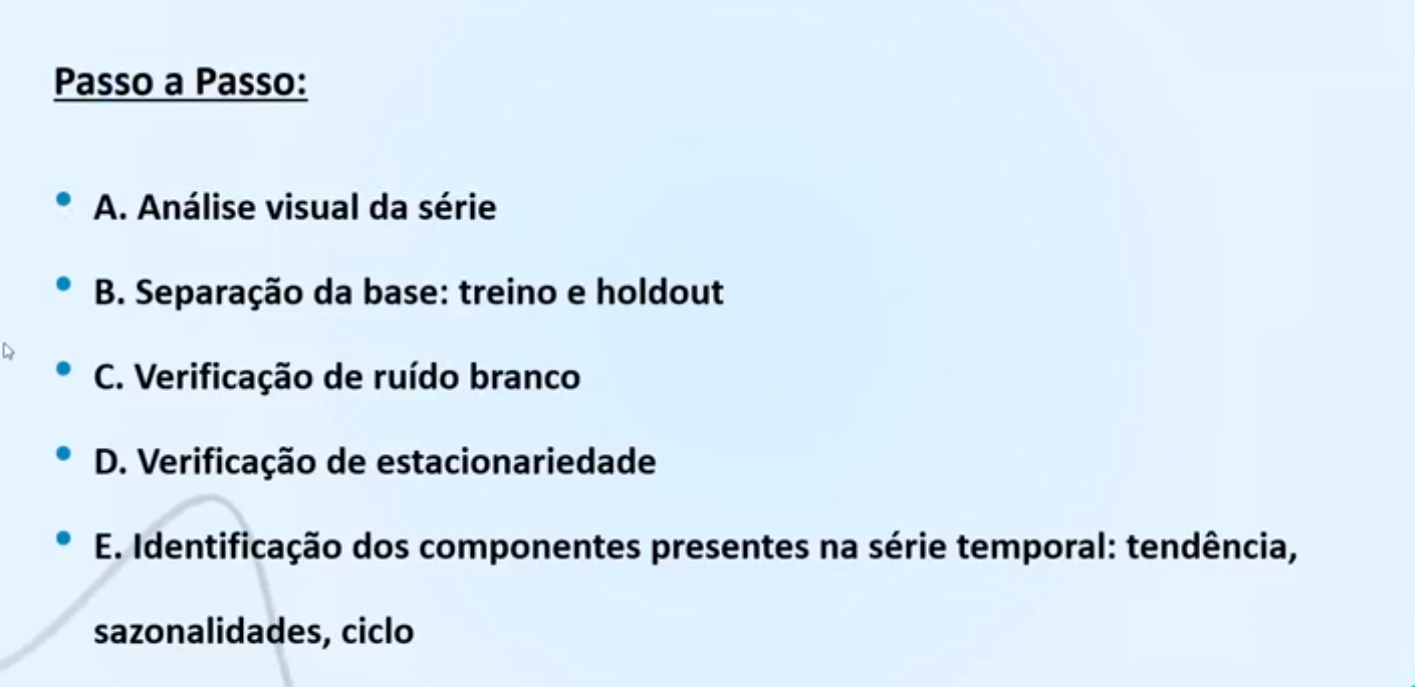

# **BIBLIOTECAS**

In [177]:
# Bibliotecas Básicas e Gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels - Ferramentas de Análise e Testes
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Statsmodels - Modelos de Previsão
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Métricas de Avaliação
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)
from math import sqrt

# Configurações de Gráficos
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

print('✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!')

✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!


# **1. CARREGAR DADOS**

In [178]:
!pip install gdown # ponte entre Google Drive e Python

In [179]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 52.4MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [180]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [181]:
# ver formato que está a data
data['Data_new'].dtype

dtype('O')

In [182]:
data['Data'].dtype

dtype('O')

In [183]:
# Deixar a data no formato de data, e não de object
data['Data'] = pd.to_datetime(pd.DataFrame({
    'day': data['Dia'],
    'month': data['Mes'],
    'year': data['Ano']
}))

In [184]:
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,2018-01-02,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,2018-01-02,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [185]:
data['Data'].dtype

dtype('<M8[ns]')

# **2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS**

Método de acumulação - soma

Intervalo de tempo - diária

In [186]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [187]:
# Filtrar apenas o Depto 4
data_depto4 = data[data['Departamento'] == 'Depto 4']

# Verificar se existe alguma venda negativa
tem_negativo = (data_depto4['Vendas'] < 0).any()
print("Existe venda negativa?", tem_negativo)

# Listar todas as linhas com vendas negativas
vendas_negativas = data_depto4[data_depto4['Vendas'] < 0]
print(vendas_negativas)

Existe venda negativa? True
             Data    Data_new  Dia_da_semana  Dia  Mes   Ano  Empresa  \
288456 2020-11-23  11/23/2020              2   23   11  2020       23   

        Feriado  Pagamento  Vale  Vendas Departamento     Seção  
288456        0          0     0   -5.66      Depto 4  Seção 20  


In [188]:
# Substituir as linhas negativas

df_depto = data[data['Departamento'] == 'Depto 4'].copy()

# Identificar dinamicamente os índices de todas as linhas que contêm vendas negativas
indices_com_erro = df_depto[df_depto['Vendas'] < 0].index

if len(indices_com_erro) > 0:
    print(f"Detectadas {len(indices_com_erro)} linhas com vendas negativas.")

    # Iterar de forma puramente dinâmica sobre os índices com erro
    for idx in indices_com_erro:
        # Extrai o mês e o ano DIRETAMENTE da linha que apresentou o erro
        mes_dinamico = df_depto.loc[idx, 'Mes']
        ano_dinamico = df_depto.loc[idx, 'Ano']
        valor_original = df_depto.loc[idx, 'Vendas']

        # Filtra a base para calcular a média apenas das vendas válidas (>= 0)
        # do mesmo mês e ano que foram identificados acima
        filtro_periodo_valido = (
            (df_depto['Mes'] == mes_dinamico) &
            (df_depto['Ano'] == ano_dinamico) &
            (df_depto['Vendas'] >= 0)
        )
        media_periodo = df_depto.loc[filtro_periodo_valido, 'Vendas'].mean()

        # Substitui o valor negativo na linha exata usando o índice
        df_depto.loc[idx, 'Vendas'] = media_periodo
        print(f"   Período identificado: {mes_dinamico:02d}/{ano_dinamico}")
        print(f"   Valor corrigido de {valor_original} para a média de {media_periodo:.2f}\n")
else:
    print("Nenhum valor negativo encontrado. A base está limpa!")

# Validação final automática
restou_negativo = (df_depto['Vendas'] < 0).any()
print("Ainda existem valores negativos na série?", restou_negativo)

Detectadas 1 linhas com vendas negativas.
   Período identificado: 11/2020
   Valor corrigido de -5.66 para a média de 34666.02

Ainda existem valores negativos na série? False


In [189]:
df_depto

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
20,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,73241.03,Depto 4,Seção 18
21,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,71675.73,Depto 4,Seção 19
22,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,120764.96,Depto 4,Seção 20
23,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,90562.58,Depto 4,Seção 21
24,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,4934.41,Depto 4,Seção 22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306996,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,36454.57,Depto 4,Seção 19
306997,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,46405.58,Depto 4,Seção 20
306998,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,55328.16,Depto 4,Seção 21
307000,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,77382.53,Depto 4,Seção 18


In [190]:
vendas_dia = (
    data_depto4
    .groupby("Data", as_index=False)
    .agg({
        "Vendas": "sum",
        "Ano": "first",
        "Mes": "first",
        "Dia": "first",
        "Dia_da_semana": "first",
        "Feriado": "max",
        "Pagamento": "max",
        "Vale": "max"
    })
)

vendas_dia.head()

,Data,Vendas,Ano,Mes,Dia,Dia_da_semana,Feriado,Pagamento,Vale
0,2018-01-02,1812134.19,2018,1,2,3,0,0,0
1,2018-01-03,1622115.60,2018,1,3,4,0,0,0
2,2018-01-04,1486888.42,2018,1,4,5,0,0,0
3,2018-01-05,2015469.36,2018,1,5,6,0,1,0
4,2018-01-06,2678387.64,2018,1,6,7,0,0,0


In [191]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [192]:
vendas_dia['Ano'] = vendas_dia['Data'].dt.year

vendas_dia.head(10)

,Data,Vendas,Ano,Mes,Dia,Dia_da_semana,Feriado,Pagamento,Vale
0,2018-01-02,1812134.19,2018,1,2,3,0,0,0
1,2018-01-03,1622115.60,2018,1,3,4,0,0,0
2,2018-01-04,1486888.42,2018,1,4,5,0,0,0
3,2018-01-05,2015469.36,2018,1,5,6,0,1,0
4,2018-01-06,2678387.64,2018,1,6,7,0,0,0
5,2018-01-07,1120660.99,2018,1,7,1,0,0,0
6,2018-01-08,1600882.79,2018,1,8,2,0,0,0
7,2018-01-09,1963629.68,2018,1,9,3,0,0,0
8,2018-01-10,1667902.81,2018,1,10,4,0,0,0
9,2018-01-11,1457775.73,2018,1,11,5,0,0,0


In [193]:
# TRATAMENTO DE DADOS FALTANTES - DIAS QUE NÃO HOUVERAM VENDAS

# Definir o calendário completo
vendas_dia_temp = vendas_dia.set_index('Data')
data_inicio = vendas_dia_temp.index.min()
data_fim = vendas_dia_temp.index.max()
calendario_completo = pd.date_range(start=data_inicio, end=data_fim, freq='D')

# Reindexar a série temporária
vendas_reindexado = vendas_dia_temp.reindex(calendario_completo)

# Identificar datas faltantes APÓS a reindexação
datas_faltantes = vendas_reindexado[vendas_reindexado['Vendas'].isna()].index
total_faltantes = len(datas_faltantes)

# Imprimir diagnóstico das datas faltantes
print(f"Havia um total de {total_faltantes} datas faltantes na série original.")

if total_faltantes > 0:
    print("\n--- Lista das datas faltantes identificadas ---")
    for data_faltante in datas_faltantes:
        print(data_faltante.date())
else:
    print("\nNenhuma data faltante encontrada!")

# Tratamento: Interpolação Linear para preenchimento dos NaNs
vendas_dia_completo = vendas_reindexado.copy()
vendas_dia_completo['Vendas'] = vendas_dia_completo['Vendas'].interpolate(method='linear')
vendas_dia_completo.index.name = 'Data'

# Validação final
print("\n--- Verificação após o tratamento ---")
print(f"Quantidade de NaNs restantes: {vendas_dia_completo['Vendas'].isna().sum()}")

Havia um total de 6 datas faltantes na série original.

--- Lista das datas faltantes identificadas ---
2018-12-25
2019-01-01
2019-12-25
2020-01-01
2020-12-25
2021-01-01

--- Verificação após o tratamento ---
Quantidade de NaNs restantes: 0


In [194]:
vendas_dia_completo

,Vendas,Ano,Mes,Dia,Dia_da_semana,Feriado,Pagamento,Vale
Data,,,,,,,,
2018-01-02,1812134.19,2018.0,1.0,2.0,3.0,0.0,0.0,0.0
2018-01-03,1622115.60,2018.0,1.0,3.0,4.0,0.0,0.0,0.0
2018-01-04,1486888.42,2018.0,1.0,4.0,5.0,0.0,0.0,0.0
2018-01-05,2015469.36,2018.0,1.0,5.0,6.0,0.0,1.0,0.0
2018-01-06,2678387.64,2018.0,1.0,6.0,7.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
2021-02-24,2025751.85,2021.0,2.0,24.0,4.0,0.0,0.0,0.0
2021-02-25,2216224.47,2021.0,2.0,25.0,5.0,0.0,0.0,1.0
2021-02-26,3098829.40,2021.0,2.0,26.0,6.0,0.0,0.0,0.0


In [195]:
vendas_dia_completo = vendas_dia_completo.reset_index()

In [196]:
vendas_dia_completo['Data'].dtype

dtype('<M8[ns]')

In [197]:
vendas_dia_completo['Data'] = pd.to_datetime(vendas_dia_completo['Data'])

# **3. ANÁLISE VISUAL E IDENTIFICAÇÃO DE COMPONENTES**

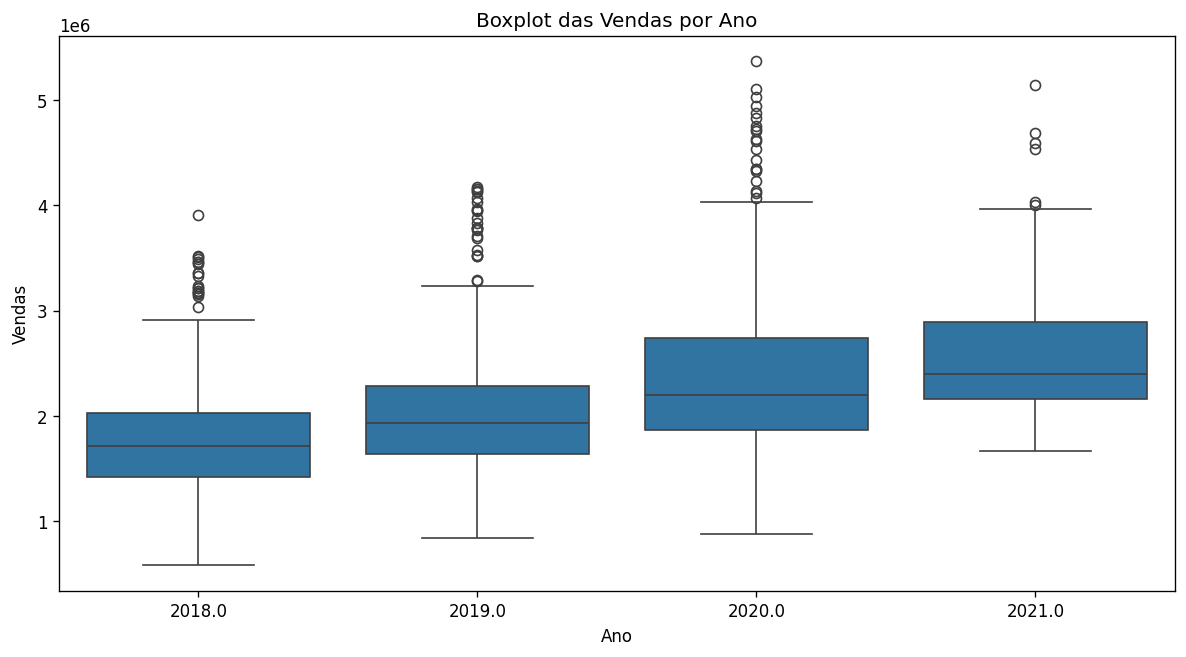

In [198]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia_completo,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [199]:
vendas_dia_completo.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018.0,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019.0,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020.0,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021.0,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


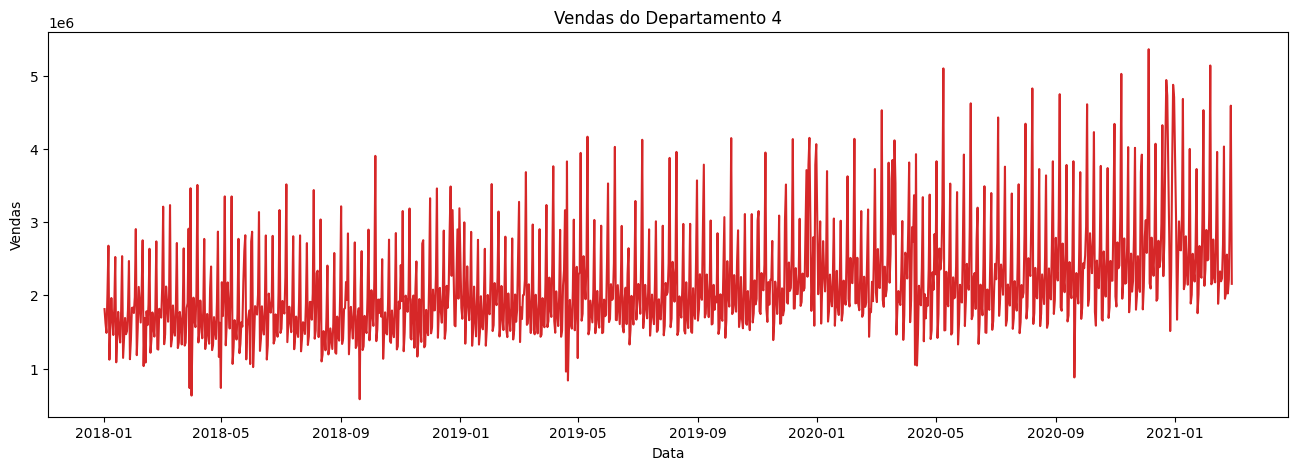

In [200]:
# Visualizando a série temporal

def plot_df(vendas_dia_completo, x, y, title="", xlabel='Data', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia_completo=vendas_dia_completo,
    x=vendas_dia_completo['Data'],
    y=vendas_dia_completo['Vendas'],
    title='Vendas do Departamento 4'
)

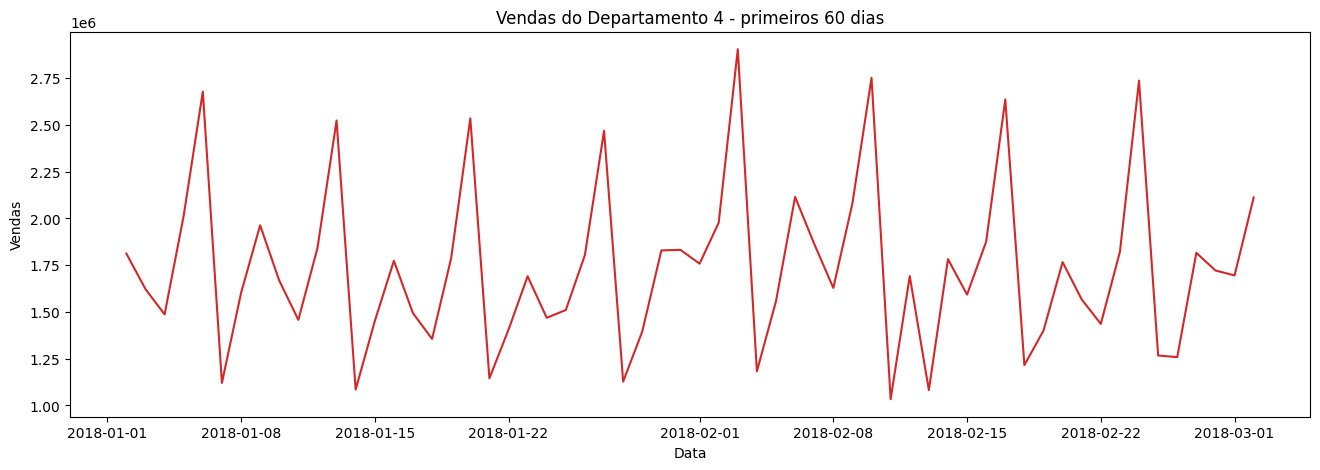

In [201]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia_completo = vendas_dia_completo.sort_values('Data')

trecho = vendas_dia_completo.iloc[:60]

plot_df(
    vendas_dia_completo=trecho,
    x=trecho['Data'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

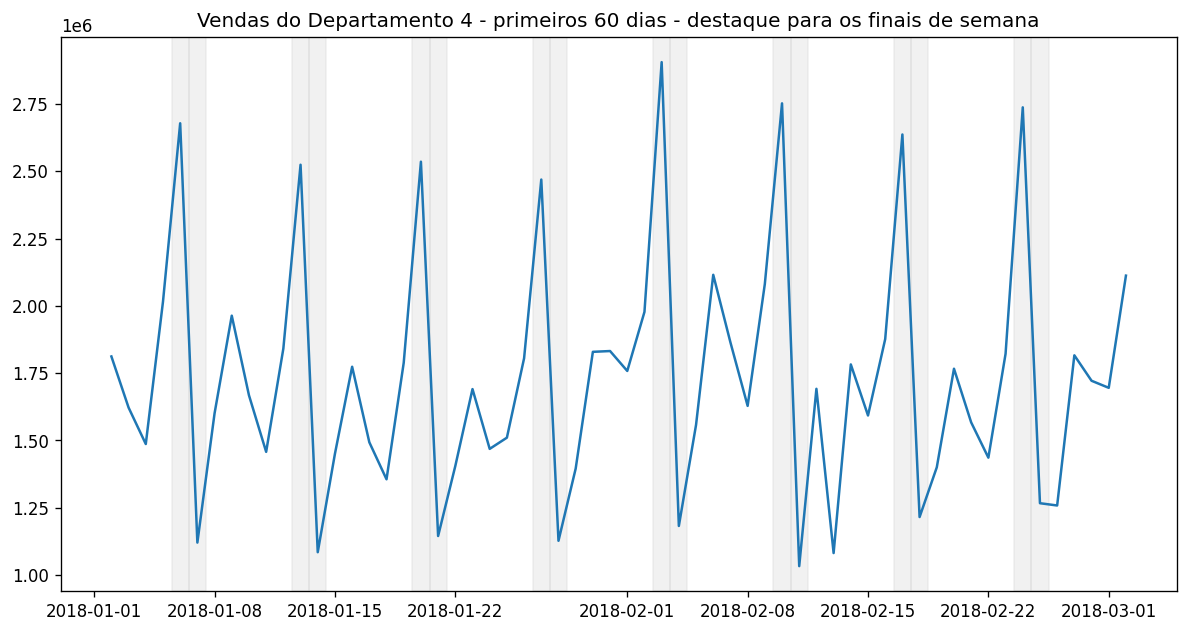

In [202]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho['Data'], trecho['Vendas'])

# destacar finais de semana
for data in trecho.loc[trecho['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )
ax.set_title('Vendas do Departamento 4 - primeiros 60 dias - destaque para os finais de semana')
plt.show()

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

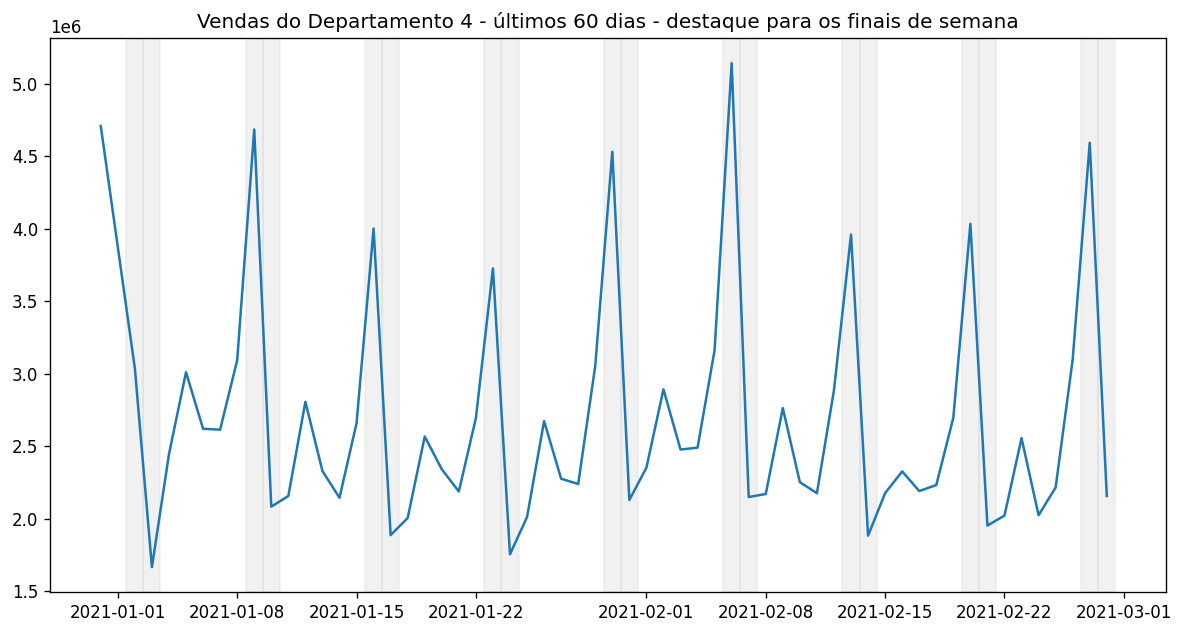

In [203]:
trecho_fim = vendas_dia_completo.tail(60)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho_fim['Data'], trecho_fim['Vendas'])

for data in trecho_fim.loc[trecho_fim['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )

ax.set_title('Vendas do Departamento 4 - últimos 60 dias - destaque para os finais de semana')
plt.show()

DECOMPOSIÇÃO MULTIPLICATIVA DA SÉRIE:

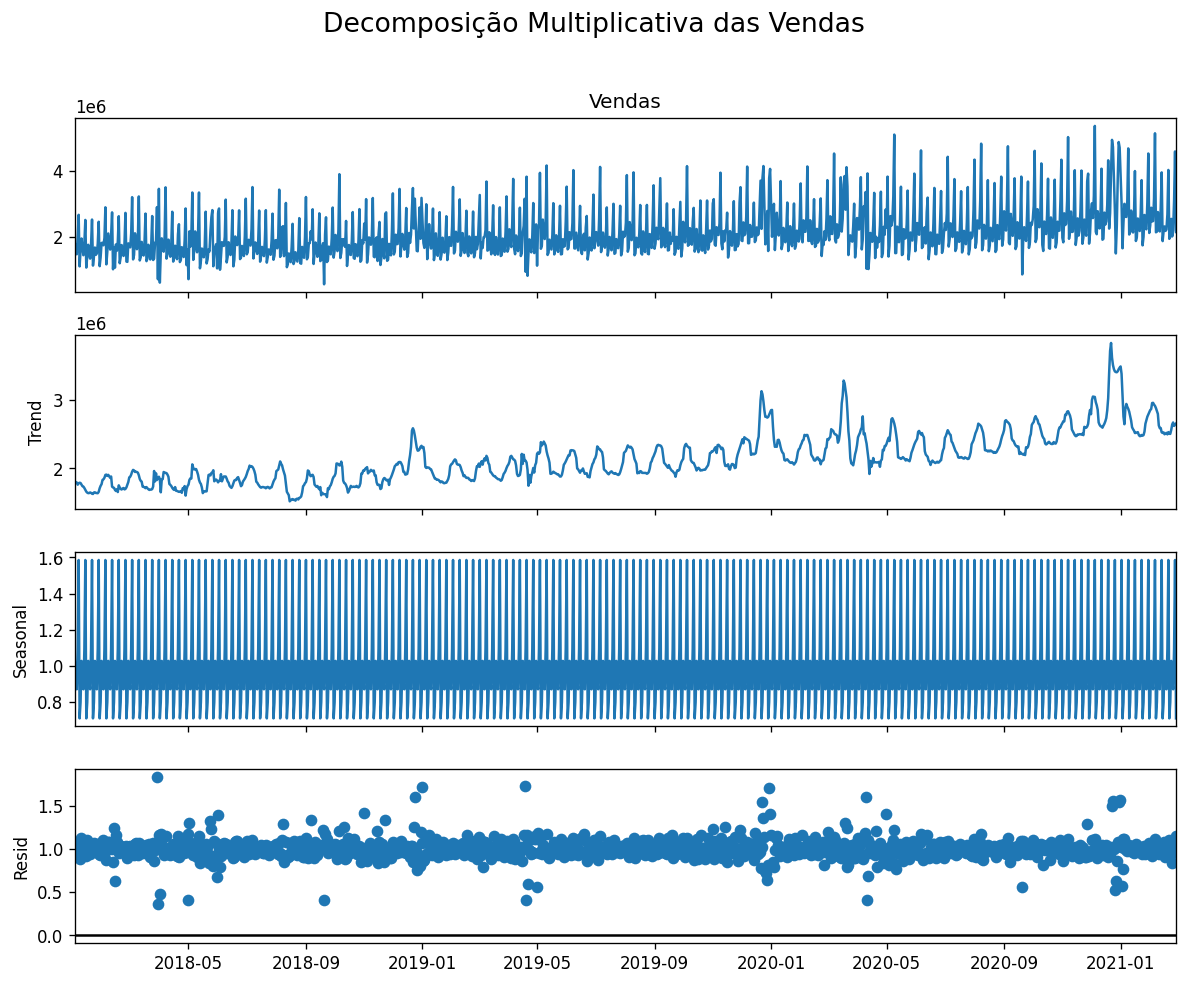

In [204]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

# Definimos a Data como índice temporariamente e extraímos apenas a coluna 'Vendas'
serie_temporal = vendas_dia_completo.set_index('Data')['Vendas']

# Executar a decomposição multiplicativa na série ajustada
result_mul = seasonal_decompose(
    serie_temporal,
    model='multiplicative',
    period=7,  # sazonalidade semanal
    extrapolate_trend='freq'
)

# Configurar e plotar os gráficos dos componentes (Tendência, Sazonalidade e Ruído)
plt.rcParams.update({'figure.figsize': (10, 8)})

result_mul.plot()

# Adiciona o título global corretamente
plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16,
    y=1.02 # Ajusta a altura para não sobrepor o gráfico superior
)

plt.tight_layout()
plt.show()

A decomposição multiplicativa confirma que a série temporal de vendas do Departamento 4 possui uma tendência de alta consistente de longo prazo (saindo de patamares próximos a 1,7 milhão em 2018 e superando 2,5 milhões a partir de 2020) e uma sazonalidade semanal altamente marcante, com fatores multiplicativos que variam de 0,7 a 1,6 vezes o valor da tendência conforme o dia da semana. O gráfico dos resíduos demonstra estabilidade geral ao redor do valor 1,0, o que valida a escolha do modelo multiplicativo, evidenciando apenas variações extremas pontuais perto de zero nas viradas de ano, causadas pelo preenchimento dos dias em que não houve faturamento registrado.

Em resumo, foi identificado por meio do Boxplot e da Decomposição:

*   Tendência: Sim, de alta ao longo dos anos.
*   Sazonalidade: Sim, fortemente semanal (período = 7).
*   Ciclo: Não há ciclos de longo prazo visíveis (como ciclos econômicos de vários anos).

# **4. SEPARAÇÃO DA SÉRIE ENTRE TREINO E TESTE**

In [205]:
df_temporario = vendas_dia_completo.set_index('Data')

# Divisão conforme as regras do exercício da DSA
treino = df_temporario.loc[:'2020-12-31']
holdout = df_temporario.loc['2021-01-01':'2021-02-28']

print(f"Base de Treinamento: {len(treino)} dias (até {treino.index.max().date()})")
print(f"Base de Holdout: {len(holdout)} dias (de {holdout.index.min().date()} até {holdout.index.max().date()})")

Base de Treinamento: 1095 dias (até 2020-12-31)
Base de Holdout: 59 dias (de 2021-01-01 até 2021-02-28)


# **5. VERIFICAÇÃO DE RUÍDO BRANCO (NA BASE DE TREINO)**

In [206]:
# Testando se a série de treino é aleatória (Ruído Branco)
resultado_lb = acorr_ljungbox(treino['Vendas'], lags=[7], return_df=True)

print("--- TESTE DE LJUNG-BOX ---")
print(resultado_lb)

p_valor_lb = resultado_lb['lb_pvalue'].values[0]
if p_valor_lb < 0.05:
    print(f"\np-valor = {p_valor_lb:.5f} (< 0.05). Rejeitamos a hipótese nula!")
    print("A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀")
else:
    print("\nA série é ruído branco. Não há padrões previsíveis.")

--- TESTE DE LJUNG-BOX ---
      lb_stat      lb_pvalue
7  863.389024  3.857778e-182

p-valor = 0.00000 (< 0.05). Rejeitamos a hipótese nula!
A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀


# **6. VERIFICAÇÃO DE ESTACIONARIEDADE (Na Base de Treino)**

In [207]:
resultado_adf = adfuller(treino['Vendas'])

print("--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---")
print(f"Estatística ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.5f}")
print("\nValores Críticos de Controle:")
for chave, valor in resultado_adf[4].items():
    print(f"   {chave}: {valor:.4f}")

# Validação do p-valor
if resultado_adf[1] < 0.05:
    print("\nAnálise: p-valor < 0.05. A série já é ESTACIONÁRIA! (d = 0) 🎯")
else:
    print("\nAnálise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️")

--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---
Estatística ADF: -1.3978
p-valor: 0.58333

Valores Críticos de Controle:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

Análise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️


# **7. VERIFICAÇÃO DE SAZONALIDADE**

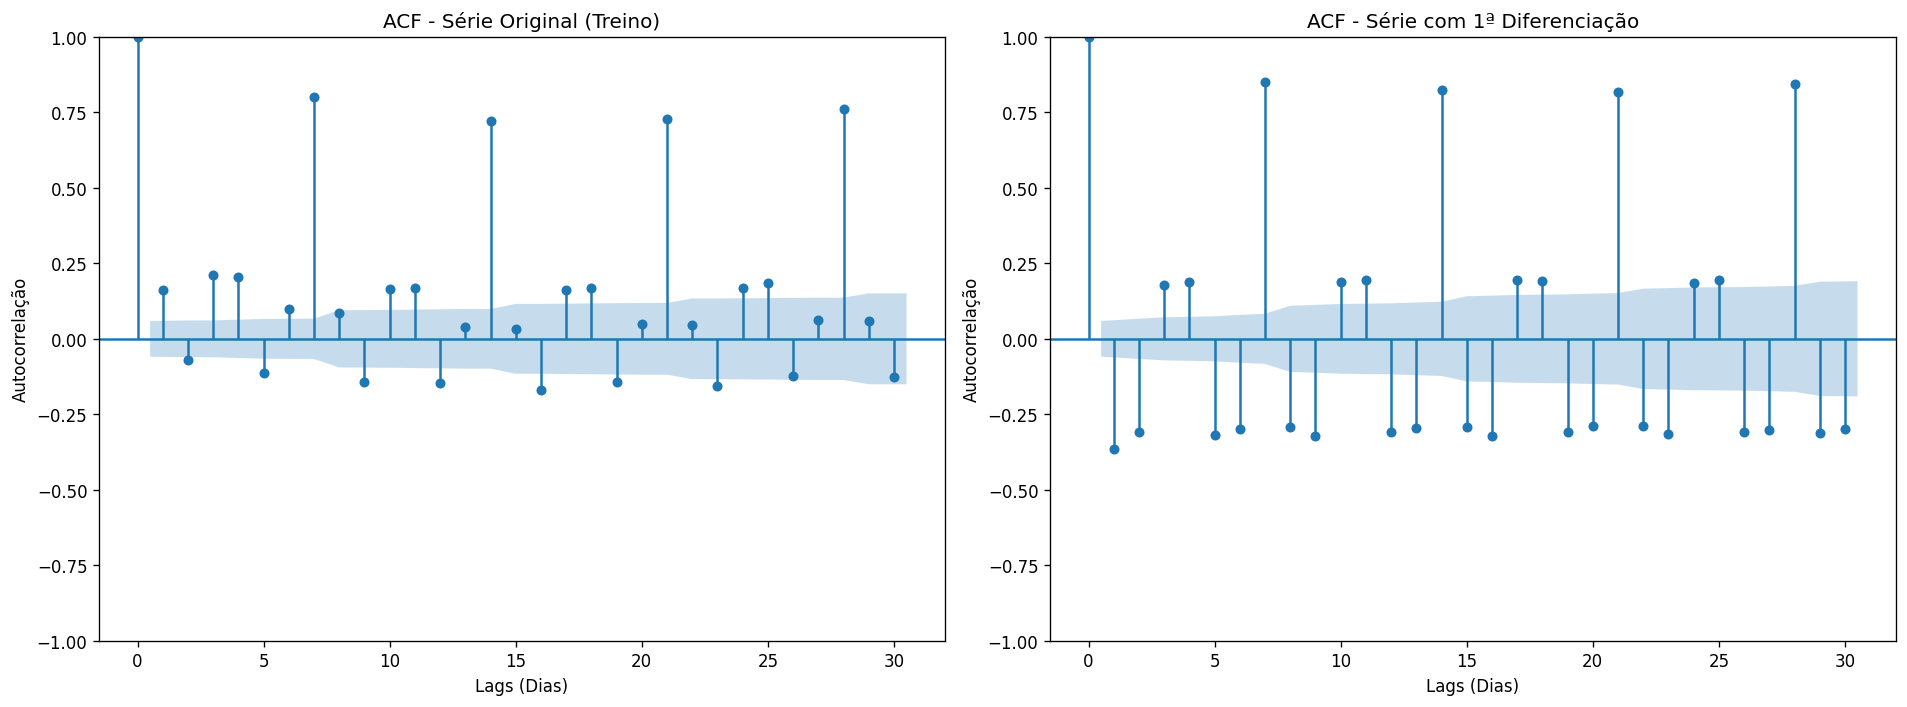

In [208]:
# Verificando autocorrelação
# Usando função ACF

# Criando a estrutura de subplots (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ACF da Série Original (Treino)
# Mostra o efeito da tendência + sazonalidade
plot_acf(treino['Vendas'], lags=30, ax=ax1, title="ACF - Série Original (Treino)")
ax1.set_xlabel("Lags (Dias)")
ax1.set_ylabel("Autocorrelação")

# 2. ACF da Série Diferenciada (Removendo a tendência)
# Mostra puramente a sazonalidade isolada
plot_acf(treino['Vendas'].diff().dropna(), lags=30, ax=ax2, title="ACF - Série com 1ª Diferenciação")
ax2.set_xlabel("Lags (Dias)")
ax2.set_ylabel("Autocorrelação")

plt.tight_layout()
plt.show()

Os gráficos de autocorrelação (ACF) confirmam e provam matematicamente a forte presença de sazonalidade semanal na série de vendas do Departamento 4. Enquanto o primeiro gráfico exibe barras persistentemente altas devido à tendência de longo prazo já identificada, o segundo gráfico — gerado após a aplicação da primeira diferenciação para estabilizar a média — isola o comportamento sazonal de forma cristalina, destacando picos intensos e significativos fora da área sombreada de controle exatamente nos lags 7, 14, 21 e 28. Essa repetição exata a cada sete dias valida estatisticamente que o volume de vendas do dia atual é fortemente dependente e correlacionado com o que aconteceu no mesmo dia da semana anterior, justificando tecnicamente o uso de modelagens sazonais (como Holt-Winters e SARIMA com período igual a 7) para o pipeline preditivo.

# **8. MODELOS**

## **8.1 Família Alisamento Exponencial: Holt-Winters Multiplicativo:**



In [209]:
treino = treino.asfreq('D')
holdout = holdout.asfreq('D')

In [210]:
# Modelos Candidatos

modelos_hw = {

    "HW_Aditivo_Aditivo":
        ExponentialSmoothing(
            treino["Vendas"],
            trend="add",
            seasonal="add",
            seasonal_periods=7
        ).fit(),

    "HW_Aditivo_Multiplicativo":
        ExponentialSmoothing(
            treino["Vendas"],
            trend="add",
            seasonal="mul",
            seasonal_periods=7
        ).fit(),

    "HW_Multiplicativo_Aditivo":
        ExponentialSmoothing(
            treino["Vendas"],
            trend="mul",
            seasonal="add",
            seasonal_periods=7
        ).fit(),

    "HW_Multiplicativo_Multiplicativo":
        ExponentialSmoothing(
            treino["Vendas"],
            trend="mul",
            seasonal="mul",
            seasonal_periods=7
        ).fit()
}

In [211]:
resultados_hw = []

for nome, modelo in modelos_hw.items():

    previsao = modelo.forecast(len(holdout))
    previsao.index = holdout.index

    mae = mean_absolute_error(
        holdout["Vendas"],
        previsao
    )

    rmse = sqrt(
        mean_squared_error(
            holdout["Vendas"],
            previsao
        )
    )

    mape = mean_absolute_percentage_error(
        holdout["Vendas"],
        previsao
    ) * 100

    wape = (
        np.sum(np.abs(holdout["Vendas"] - previsao))
        /
        np.sum(holdout["Vendas"])
    ) * 100

    residuos = modelo.resid

    lb = acorr_ljungbox(
        residuos,
        lags=[7],
        return_df=True
    )

    pvalor = lb["lb_pvalue"].iloc[0]

    ruido_branco = "SIM" if pvalor > 0.05 else "NÃO"

    resultados_hw.append({

        "Modelo": nome,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "WAPE (%)": wape,
        "p-valor Ljung-Box": pvalor,
        "Ruído Branco": ruido_branco

    })

In [212]:
comparativo_hw = (
    pd.DataFrame(resultados_hw)
      .sort_values("MAPE (%)")
      .reset_index(drop=True)
)

comparativo_hw

,Modelo,MAE,RMSE,MAPE (%),WAPE (%),p-valor Ljung-Box,Ruído Branco
0,HW_Multiplicativo_Aditivo,1.391048e+06,1.433341e+06,56.508265,51.819747,8.163826e-26,NÃO
1,HW_Aditivo_Aditivo,1.426990e+06,1.468765e+06,57.947562,53.158668,7.996887e-26,NÃO
2,HW_Multiplicativo_Multiplicativo,1.715606e+06,1.807727e+06,65.369395,63.910286,4.854392e-33,NÃO
3,HW_Aditivo_Multiplicativo,1.873390e+06,1.972764e+06,71.252644,69.788097,1.622736e-32,NÃO


In [213]:
melhor_modelo = comparativo_hw.iloc[0]["Modelo"]

print("="*60)
print("MELHOR MODELO HOLT-WINTERS")
print("="*60)
print(melhor_modelo)

MELHOR MODELO HOLT-WINTERS
HW_Multiplicativo_Aditivo


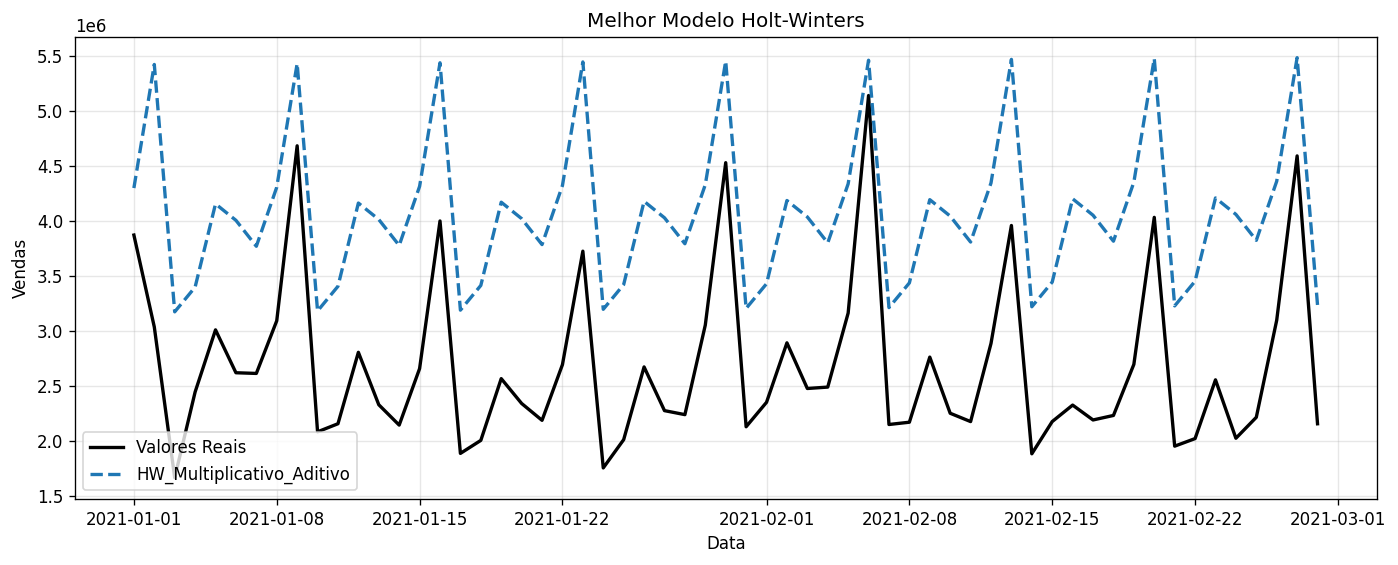

In [214]:
modelo_final = modelos_hw[melhor_modelo]

previsao = modelo_final.forecast(len(holdout))
previsao.index = holdout.index

plt.figure(figsize=(14,5))

plt.plot(
    holdout.index,
    holdout["Vendas"],
    color="black",
    linewidth=2,
    label="Valores Reais"
)

plt.plot(
    previsao.index,
    previsao,
    '--',
    linewidth=2,
    label=melhor_modelo
)

plt.title("Melhor Modelo Holt-Winters")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.grid(alpha=.3)
plt.legend()
plt.show()

In [215]:
print(modelo_final.summary())

                        ExponentialSmoothing Model Results                       
Dep. Variable:                   Vendas   No. Observations:                  1095
Model:             ExponentialSmoothing   SSE                 129020980531448.469
Optimized:                         True   AIC                           27936.273
Trend:                   Multiplicative   BIC                           27991.256
Seasonal:                      Additive   AICC                          27936.609
Seasonal Periods:                     7   Date:                  Sun, 26 Jul 2026
Box-Cox:                          False   Time:                          23:56:21
Box-Cox Coeff.:                    None                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2727953                alpha                 True
smoothing_trend 

In [216]:
print("="*60)

linha = comparativo_hw.iloc[0]

print(f"Modelo vencedor : {linha['Modelo']}")
print(f"MAE            : {linha['MAE']:,.2f}")
print(f"RMSE           : {linha['RMSE']:,.2f}")
print(f"MAPE           : {linha['MAPE (%)']:.2f}%")
print(f"WAPE           : {linha['WAPE (%)']:.2f}%")
print(f"p-valor        : {linha['p-valor Ljung-Box']:.5f}")

if linha["Ruído Branco"] == "SIM":
    print("\nOs resíduos podem ser considerados Ruído Branco.")
    print("O modelo capturou adequadamente a estrutura temporal da série.")
else:
    print("\nOs resíduos NÃO são Ruído Branco.")
    print("Ainda existe informação temporal não explicada pelo modelo.")

Modelo vencedor : HW_Multiplicativo_Aditivo
MAE            : 1,391,047.77
RMSE           : 1,433,341.34
MAPE           : 56.51%
WAPE           : 51.82%
p-valor        : 0.00000

Os resíduos NÃO são Ruído Branco.
Ainda existe informação temporal não explicada pelo modelo.


Foram avaliadas quatro configurações do modelo Holt-Winters, combinando tendências e sazonalidades aditivas e multiplicativas. O modelo com tendência multiplicativa e sazonalidade aditiva apresentou o menor erro entre as alternativas testadas (MAPE = 56,51%), sendo selecionado como o melhor representante da família Holt-Winters. Entretanto, apesar da melhora em relação às demais configurações, o erro percentual permaneceu elevado e o teste de Ljung-Box aplicado aos resíduos resultou em p-valor inferior a 0,05, indicando que os resíduos não podem ser considerados ruído branco. Dessa forma, conclui-se que o modelo não capturou completamente a estrutura temporal da série, sugerindo que abordagens mais flexíveis, como ARIMA ou SARIMA, podem representar melhor o comportamento dos dados.

## **8.2 ARIMA:**

Como já foi visto pelo teste ADF que a série precisa de uma diferenciação para ficar estacionária ($d=1$), deve-se analisar o ACF e o PACF da série já diferenciada para descobrir os parâmetros corretos.

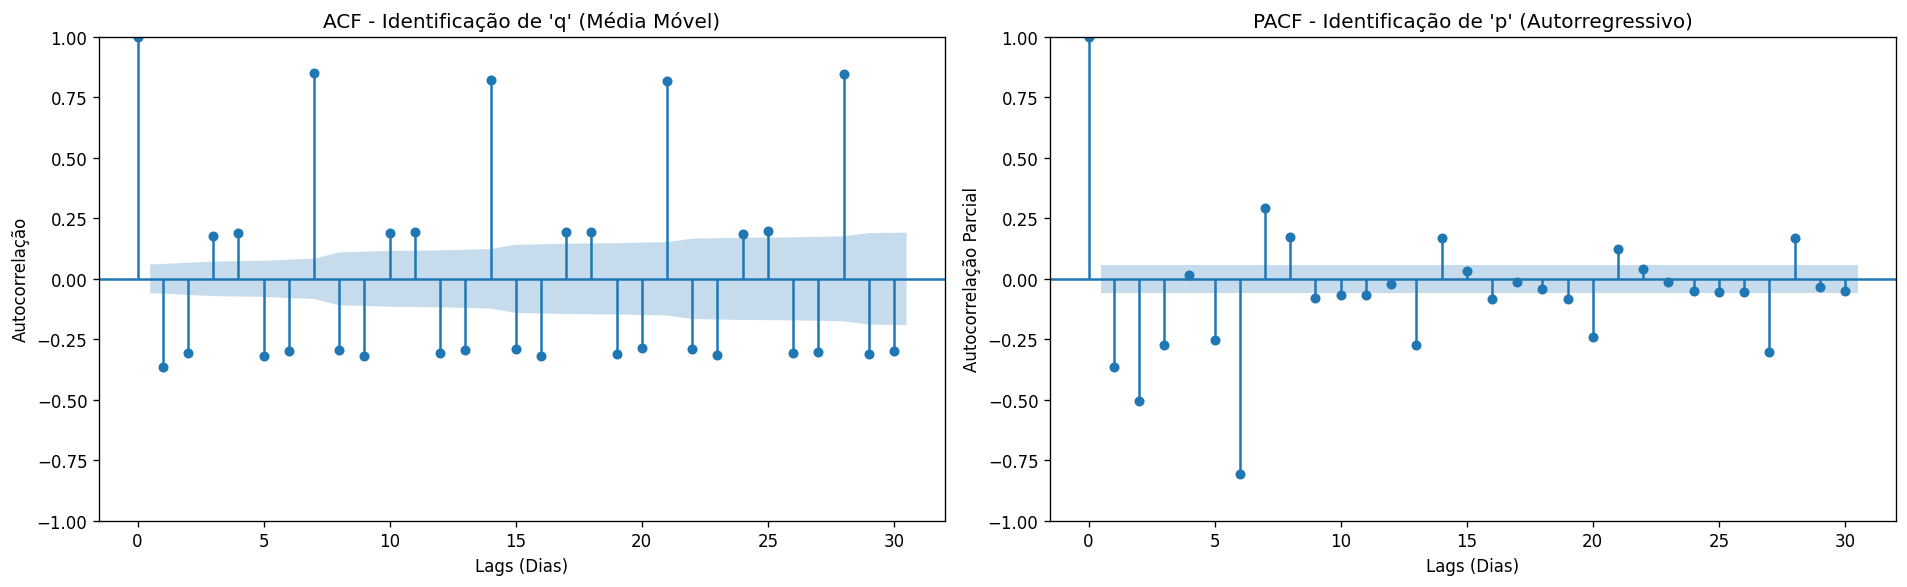

In [217]:
# Aplicando a primeira diferenciação na base de treino para estacionarizar a série
serie_diferenciada = treino['Vendas'].diff().dropna()

# Criando a estrutura de subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

# Plot do ACF (para identificar o termo de Média Móvel - q)
plot_acf(serie_diferenciada, lags=30, ax=ax1, title="ACF - Identificação de 'q' (Média Móvel)")
ax1.set_xlabel("Lags (Dias)")
ax1.set_ylabel("Autocorrelação")

# Plot do PACF (para identificar o termo Autorregressivo - p)
plot_pacf(serie_diferenciada, lags=30, ax=ax2, title="PACF - Identificação de 'p' (Autorregressivo)", method='yw')
ax2.set_xlabel("Lags (Dias)")
ax2.set_ylabel("Autocorrelação Parcial")

plt.tight_layout()
plt.show()

A série diferenciada apresentou autocorrelação significativa nos primeiros lags e forte padrão sazonal a cada sete dias, evidenciado pelos picos recorrentes na ACF. A PACF indicou componentes autorregressivos relevantes até aproximadamente o terceiro lag. Com base nesses resultados, foram selecionados modelos ARIMA com p variando entre 1 e 3, q entre 1 e 2 e d = 1, conforme indicado pelo teste ADF.

In [218]:
# Modelos candidatos

modelos_arima = {

    "ARIMA(1,1,1)": (1,1,1),
    "ARIMA(1,1,2)": (1,1,2),
    "ARIMA(2,1,1)": (2,1,1),
    "ARIMA(2,1,2)": (2,1,2),
    "ARIMA(3,1,1)": (3,1,1),
    "ARIMA(3,1,2)": (3,1,2)

}

In [219]:
resultados_arima = []

for nome, ordem in modelos_arima.items():

    print(f"Treinando {nome}...")

    modelo = ARIMA(
        treino["Vendas"],
        order=ordem,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit()

    previsao = modelo.forecast(steps=len(holdout))
    previsao.index = holdout.index

    mae = mean_absolute_error(
        holdout["Vendas"],
        previsao
    )

    rmse = sqrt(
        mean_squared_error(
            holdout["Vendas"],
            previsao
        )
    )

    mape = (
        mean_absolute_percentage_error(
            holdout["Vendas"],
            previsao
        ) * 100
    )

    wape = (
        np.sum(np.abs(holdout["Vendas"] - previsao))
        /
        np.sum(holdout["Vendas"])
    ) * 100

    lb = acorr_ljungbox(
        modelo.resid,
        lags=[7],
        return_df=True
    )

    pvalor = lb["lb_pvalue"].iloc[0]

    ruido = "SIM" if pvalor > 0.05 else "NÃO"

    resultados_arima.append({

        "Modelo": nome,
        "Ordem": ordem,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "WAPE (%)": wape,
        "p-valor Ljung-Box": pvalor,
        "Ruído Branco": ruido

    })

Treinando ARIMA(1,1,1)...
Treinando ARIMA(1,1,2)...
Treinando ARIMA(2,1,1)...
Treinando ARIMA(2,1,2)...
Treinando ARIMA(3,1,1)...
Treinando ARIMA(3,1,2)...


In [220]:
comparativo_arima = (
    pd.DataFrame(resultados_arima)
      .sort_values(["MAPE (%)","AIC"])
      .reset_index(drop=True)
)

comparativo_arima

,Modelo,Ordem,AIC,BIC,MAE,RMSE,MAPE (%),WAPE (%),p-valor Ljung-Box,Ruído Branco
0,"ARIMA(1,1,1)","(1, 1, 1)",32469.483623,32484.470921,659477.822540,802192.464446,25.544406,24.567074,1.361132e-181,NÃO
1,"ARIMA(1,1,2)","(1, 1, 2)",32383.884988,32403.864388,667976.585042,806626.274203,26.076329,24.883673,1.435348e-146,NÃO
2,"ARIMA(3,1,2)","(3, 1, 2)",32339.689866,32369.658965,727496.253110,850252.422226,28.842377,27.100918,2.235164e-123,NÃO
3,"ARIMA(3,1,1)","(3, 1, 1)",32346.753466,32371.727716,727834.057641,850397.623338,28.861646,27.113502,2.197811e-123,NÃO
4,"ARIMA(2,1,2)","(2, 1, 2)",32355.220336,32380.194586,749866.902443,865671.409555,29.987744,27.934276,1.215700e-120,NÃO
5,"ARIMA(2,1,1)","(2, 1, 1)",32379.601548,32399.584613,755888.539445,870426.176409,30.265129,28.158596,2.114223e-119,NÃO


In [221]:
melhor_modelo = comparativo_arima.iloc[0]["Modelo"]
melhor_ordem = comparativo_arima.iloc[0]["Ordem"]

print("="*70)
print("MELHOR MODELO ARIMA")
print("="*70)
print(melhor_modelo)
print(melhor_ordem)

MELHOR MODELO ARIMA
ARIMA(1,1,1)
(1, 1, 1)


In [222]:
modelo_final = ARIMA(

    treino["Vendas"],
    order=melhor_ordem,
    enforce_stationarity=False,
    enforce_invertibility=False

).fit()

previsao = modelo_final.forecast(len(holdout))
previsao.index = holdout.index

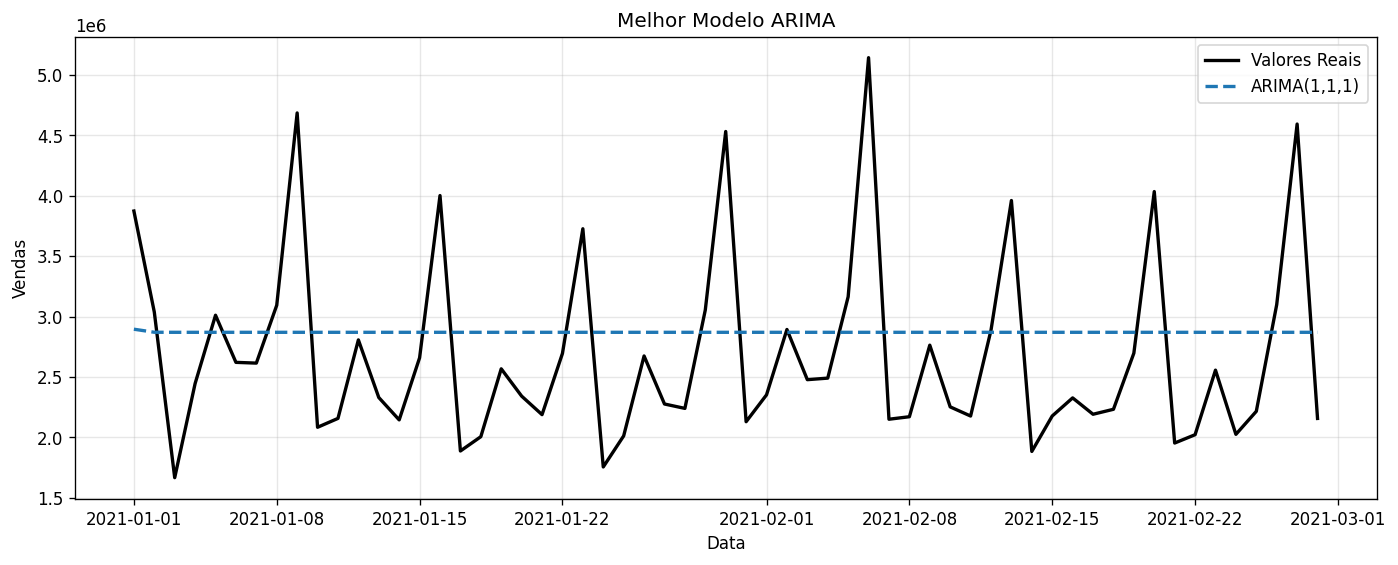

In [223]:
plt.figure(figsize=(14,5))

plt.plot(
    holdout.index,
    holdout["Vendas"],
    color="black",
    linewidth=2,
    label="Valores Reais"
)

plt.plot(
    previsao.index,
    previsao,
    '--',
    linewidth=2,
    label=melhor_modelo
)

plt.title("Melhor Modelo ARIMA")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.grid(alpha=.3)
plt.legend()
plt.show()

In [224]:
print(modelo_final.summary())

                               SARIMAX Results                                
Dep. Variable:                 Vendas   No. Observations:                 1095
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -16231.742
Date:                Sun, 26 Jul 2026   AIC                          32469.484
Time:                        23:56:36   BIC                          32484.471
Sample:                    01-02-2018   HQIC                         32475.155
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0139      0.039      0.354      0.723      -0.063       0.091
ma.L1         -0.9764      0.010    -98.746      0.000      -0.996      -0.957
sigma2      6.013e+11   1.59e-14   3.78e+25      0.0

In [225]:
linha = comparativo_arima.iloc[0]

print("="*70)

print(f"Modelo vencedor : {linha['Modelo']}")
print(f"AIC             : {linha['AIC']:.2f}")
print(f"BIC             : {linha['BIC']:.2f}")
print(f"MAE             : {linha['MAE']:,.2f}")
print(f"RMSE            : {linha['RMSE']:,.2f}")
print(f"MAPE            : {linha['MAPE (%)']:.2f}%")
print(f"WAPE            : {linha['WAPE (%)']:.2f}%")
print(f"p-valor         : {linha['p-valor Ljung-Box']:.5f}")

if linha["Ruído Branco"] == "SIM":

    print("\nOs resíduos podem ser considerados Ruído Branco.")
    print("O modelo capturou adequadamente a estrutura temporal da série.")

else:

    print("\nOs resíduos NÃO são Ruído Branco.")
    print("Ainda existe dependência temporal não explicada.")

Modelo vencedor : ARIMA(1,1,1)
AIC             : 32469.48
BIC             : 32484.47
MAE             : 659,477.82
RMSE            : 802,192.46
MAPE            : 25.54%
WAPE            : 24.57%
p-valor         : 0.00000

Os resíduos NÃO são Ruído Branco.
Ainda existe dependência temporal não explicada.


Embora o ARIMA(1,1,1) tenha sido selecionado com base na análise da ACF e PACF da série diferenciada, observou-se que suas previsões convergiram para valores próximos da média histórica, não conseguindo reproduzir o comportamento cíclico semanal presente na série. Esse resultado evidencia a limitação do ARIMA em modelar componentes sazonais, justificando a utilização do modelo SARIMA, que incorpora explicitamente a sazonalidade.

## **8.3 SARIMA:**

A análise da ACF da série diferenciada apresentou picos recorrentes nos lags 7, 14, 21 e 28, indicando sazonalidade semanal. Dessa forma, optou-se pela utilização do modelo SARIMA, que incorpora componentes autorregressivos, de média móvel e diferenciação tanto na parte não sazonal quanto na sazonal.

Como no ARIMA o melhor foi (1,1,1), testou-se apenas a parte sazonal.

In [226]:
modelos_sarima = {

    "SARIMA(1,1,1)(1,1,0,7)":
        ((1,1,1),(1,1,0,7)),

    "SARIMA(1,1,1)(0,1,1,7)":
        ((1,1,1),(0,1,1,7)),

    "SARIMA(1,1,1)(1,1,1,7)":
        ((1,1,1),(1,1,1,7))

}

In [227]:
# Modelos candidatos

resultados_sarima = []

for nome, parametros in modelos_sarima.items():

    ordem = parametros[0]
    ordem_sazonal = parametros[1]

    print(f"Treinando {nome}...")

    modelo = SARIMAX(

        treino["Vendas"],
        order=ordem,
        seasonal_order=ordem_sazonal,
        enforce_stationarity=False,
        enforce_invertibility=False

    ).fit(disp=False)

    previsao = modelo.forecast(steps=len(holdout))
    previsao.index = holdout.index

    mae = mean_absolute_error(
        holdout["Vendas"],
        previsao
    )

    rmse = sqrt(
        mean_squared_error(
            holdout["Vendas"],
            previsao
        )
    )

    mape = (
        mean_absolute_percentage_error(
            holdout["Vendas"],
            previsao
        ) * 100
    )

    wape = (
        np.sum(np.abs(holdout["Vendas"] - previsao))
        /
        np.sum(holdout["Vendas"])
    ) * 100

    lb = acorr_ljungbox(
        modelo.resid,
        lags=[7],
        return_df=True
    )

    pvalor = lb["lb_pvalue"].iloc[0]

    ruido = "SIM" if pvalor > 0.05 else "NÃO"

    resultados_sarima.append({

        "Modelo": nome,
        "Order": ordem,
        "Seasonal": ordem_sazonal,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "WAPE (%)": wape,
        "p-valor Ljung-Box": pvalor,
        "Ruído Branco": ruido

    })

Treinando SARIMA(1,1,1)(1,1,0,7)...
Treinando SARIMA(1,1,1)(0,1,1,7)...
Treinando SARIMA(1,1,1)(1,1,1,7)...


In [228]:
comparativo_sarima = (

    pd.DataFrame(resultados_sarima)
      .sort_values(["AIC","MAPE (%)"])
      .reset_index(drop=True)

)

comparativo_sarima

,Modelo,Order,Seasonal,AIC,BIC,MAE,RMSE,MAPE (%),WAPE (%),p-valor Ljung-Box,Ruído Branco
0,"SARIMA(1,1,1)(0,1,1,7)","(1, 1, 1)","(0, 1, 1, 7)",30691.862366,30711.793817,2.329760e+06,2.460015e+06,94.678891,86.788961,1.647047e-04,NÃO
1,"SARIMA(1,1,1)(1,1,1,7)","(1, 1, 1)","(1, 1, 1, 7)",30692.770537,30717.684851,2.270004e+06,2.395016e+06,92.244443,84.562909,3.678562e-04,NÃO
2,"SARIMA(1,1,1)(1,1,0,7)","(1, 1, 1)","(1, 1, 0, 7)",30894.737880,30914.673039,2.150065e+06,2.512334e+06,89.419469,80.094892,9.816206e-11,NÃO


In [229]:
melhor_modelo = comparativo_sarima.iloc[0]["Modelo"]
melhor_ordem = comparativo_sarima.iloc[0]["Order"]
melhor_sazonal = comparativo_sarima.iloc[0]["Seasonal"]

print("="*70)
print("MELHOR MODELO SARIMA")
print("="*70)
print(melhor_modelo)
print("Order:", melhor_ordem)
print("Seasonal:", melhor_sazonal)

MELHOR MODELO SARIMA
SARIMA(1,1,1)(0,1,1,7)
Order: (1, 1, 1)
Seasonal: (0, 1, 1, 7)


In [230]:
modelo_final = SARIMAX(

    treino["Vendas"],
    order=melhor_ordem,
    seasonal_order=melhor_sazonal,
    enforce_stationarity=False,
    enforce_invertibility=False

).fit(disp=False)

previsao = modelo_final.forecast(len(holdout))
previsao.index = holdout.index

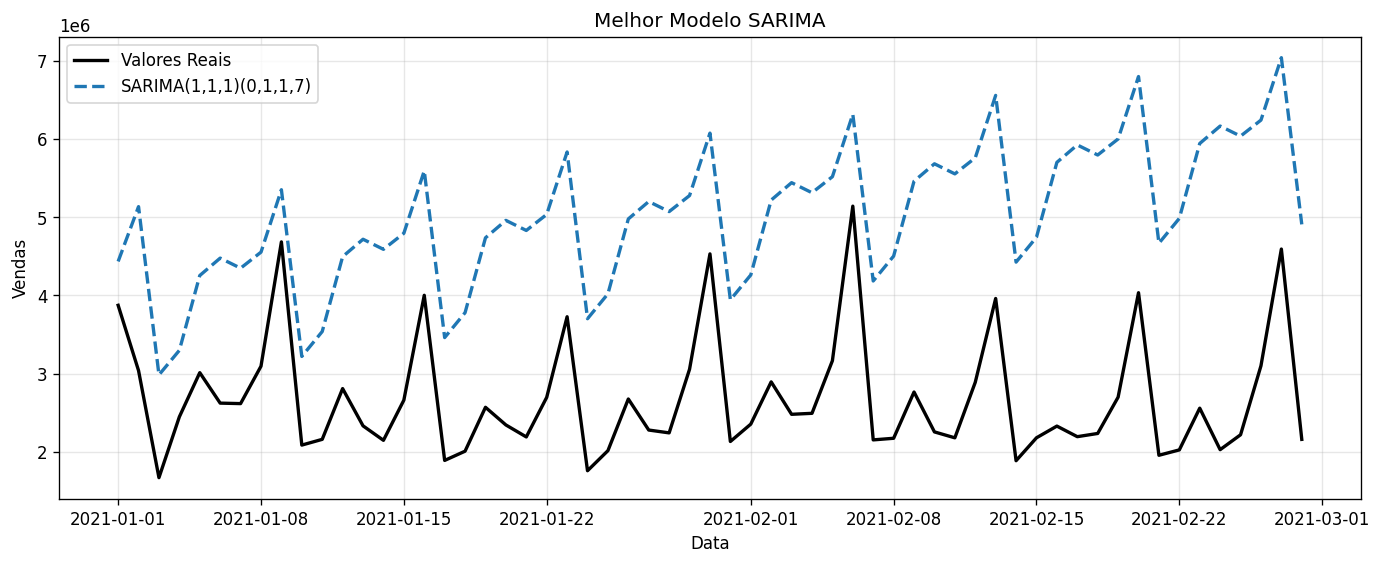

In [231]:
plt.figure(figsize=(14,5))

plt.plot(

    holdout.index,
    holdout["Vendas"],
    color="black",
    linewidth=2,
    label="Valores Reais"

)

plt.plot(

    previsao.index,
    previsao,
    "--",
    linewidth=2,
    label=melhor_modelo

)

plt.title("Melhor Modelo SARIMA")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.grid(alpha=.3)
plt.legend()
plt.show()

In [232]:
print(modelo_final.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Vendas   No. Observations:                 1095
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -15341.931
Date:                           Sun, 26 Jul 2026   AIC                          30691.862
Time:                                   23:56:46   BIC                          30711.794
Sample:                               01-02-2018   HQIC                         30699.410
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2034      0.032      6.361      0.000       0.141       0.266
ma.L1         -0.7582      0.023    -32.897

In [233]:
linha = comparativo_sarima.iloc[0]

print("="*70)
print(f"Modelo vencedor : {linha['Modelo']}")
print(f"AIC             : {linha['AIC']:.2f}")
print(f"BIC             : {linha['BIC']:.2f}")
print(f"MAE             : {linha['MAE']:,.2f}")
print(f"RMSE            : {linha['RMSE']:,.2f}")
print(f"MAPE            : {linha['MAPE (%)']:.2f}%")
print(f"WAPE            : {linha['WAPE (%)']:.2f}%")
print(f"p-valor         : {linha['p-valor Ljung-Box']:.5f}")

if linha["Ruído Branco"] == "SIM":

    print("\nOs resíduos podem ser considerados Ruído Branco.")
    print("O modelo capturou adequadamente a estrutura temporal da série.")

else:

    print("\nOs resíduos NÃO são Ruído Branco.")
    print("Ainda existe dependência temporal não explicada.")

Modelo vencedor : SARIMA(1,1,1)(0,1,1,7)
AIC             : 30691.86
BIC             : 30711.79
MAE             : 2,329,760.33
RMSE            : 2,460,015.22
MAPE            : 94.68%
WAPE            : 86.79%
p-valor         : 0.00016

Os resíduos NÃO são Ruído Branco.
Ainda existe dependência temporal não explicada.


A partir da análise da ACF, foi identificada uma sazonalidade semanal na série temporal, justificando a utilização do modelo SARIMA. Entre os modelos avaliados, o SARIMA(1,1,1)(0,1,1,7) apresentou o melhor desempenho segundo os critérios de comparação adotados. Entretanto, ao avaliar as previsões no conjunto de teste, observou-se que o modelo, embora tenha sido capaz de reproduzir o padrão sazonal semanal da série, apresentou superestimação dos valores de vendas, resultando em erros elevados de previsão (MAE, RMSE, MAPE e WAPE). Além disso, o teste de Ljung-Box aplicado aos resíduos apresentou p-valor inferior a 0,05, indicando que os resíduos não podem ser considerados ruído branco. Esse resultado demonstra que ainda existe dependência temporal não capturada pelo modelo, sugerindo que fatores externos ao comportamento histórico da série influenciam significativamente as vendas diárias. Dessa forma, conclui-se que, embora o SARIMA represente um avanço em relação aos modelos sem componente sazonal, sua capacidade preditiva ainda é limitada para a série analisada, indicando a necessidade de incorporar variáveis exógenas ou utilizar modelos mais flexíveis em trabalhos futuros.

# **8.4 SARIMAX:**

Os modelos univariados avaliados anteriormente apresentaram limitações para explicar completamente a dinâmica das vendas diárias, indicando que fatores externos podem influenciar a série temporal. Dessa forma, foi ajustado um modelo SARIMAX, incorporando variáveis exógenas disponíveis na base de dados (Feriado, Pagamento e Vale), com o objetivo de verificar se essas informações adicionais melhoram o desempenho preditivo.

In [251]:
serie_temporal_sarimax = vendas_dia_completo.copy()

serie_temporal_sarimax["Data"] = pd.to_datetime(
    serie_temporal_sarimax["Data"]
)

serie_temporal_sarimax.set_index("Data", inplace=True)

serie_temporal_sarimax.head()

,Vendas,Ano,Mes,Dia,Dia_da_semana,Feriado,Pagamento,Vale
Data,,,,,,,,
2018-01-02,1812134.19,2018.0,1.0,2.0,3.0,0.0,0.0,0.0
2018-01-03,1622115.60,2018.0,1.0,3.0,4.0,0.0,0.0,0.0
2018-01-04,1486888.42,2018.0,1.0,4.0,5.0,0.0,0.0,0.0
2018-01-05,2015469.36,2018.0,1.0,5.0,6.0,0.0,1.0,0.0
2018-01-06,2678387.64,2018.0,1.0,6.0,7.0,0.0,0.0,0.0


In [252]:
# Preenche as variáveis exógenas ausentes
serie_temporal_sarimax["Feriado"] = serie_temporal_sarimax["Feriado"].fillna(1)
serie_temporal_sarimax["Pagamento"] = serie_temporal_sarimax["Pagamento"].fillna(0)
serie_temporal_sarimax["Vale"] = serie_temporal_sarimax["Vale"].fillna(0)

In [253]:
treino_sarimax = serie_temporal_sarimax.loc[:'2020-12-31'].copy()
holdout_sarimax = serie_temporal_sarimax.loc['2021-01-01':].copy()

In [254]:
serie_temporal_sarimax = serie_temporal_sarimax.asfreq("D")

In [259]:
variaveis = ["Feriado"]

X_treino = treino_sarimax[variaveis]
X_holdout = holdout_sarimax[variaveis]

y_treino = treino_sarimax["Vendas"]
y_holdout = holdout_sarimax["Vendas"]

In [260]:
# Verificar valores ausentes
print(X_treino.isna().sum())

Feriado    0
dtype: int64


In [266]:
modelo_sarimax = SARIMAX(
    endog=y_treino,
    exog=X_treino,
    order=(1,1,1),
    seasonal_order=(0,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarimax = modelo_sarimax.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [267]:
print(resultado_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Vendas   No. Observations:                 1095
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -15325.951
Date:                           Mon, 27 Jul 2026   AIC                          30659.901
Time:                                   00:04:59   BIC                          30679.833
Sample:                               01-02-2018   HQIC                         30667.449
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Feriado    -4.571e+05   4.28e+04    -10.681      0.000   -5.41e+05   -3.73e+05
ma.L1         -0.5545      0.022    -24.994

In [268]:
previsao = resultado_sarimax.forecast(
    steps=len(y_holdout),
    exog=X_holdout
)

In [269]:
mae = mean_absolute_error(y_holdout, previsao)

rmse = np.sqrt(
    mean_squared_error(
        y_holdout,
        previsao
    )
)

mape = (
    mean_absolute_percentage_error(
        y_holdout,
        previsao
    )
) * 100

wape = (
    np.abs(
        y_holdout - previsao
    ).sum()
    /
    y_holdout.sum()
) * 100

print("="*60)
print("RESULTADOS DO SARIMAX")
print("="*60)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"WAPE : {wape:.2f}%")

RESULTADOS DO SARIMAX
MAE  : 2,854,827.29
RMSE : 2,995,938.44
MAPE : 115.50%
WAPE : 106.35%


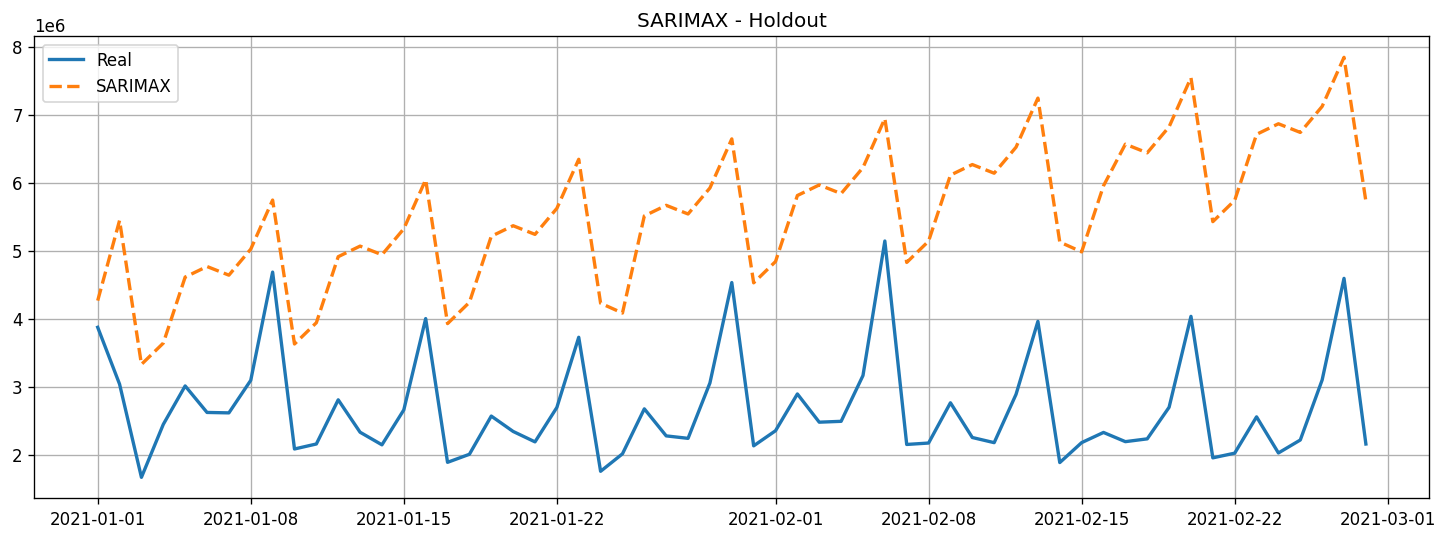

In [270]:
plt.figure(figsize=(15,5))

plt.plot(
    y_holdout,
    label="Real",
    linewidth=2
)

plt.plot(
    previsao,
    '--',
    linewidth=2,
    label="SARIMAX"
)

plt.title("SARIMAX - Holdout")
plt.legend()
plt.grid(True)
plt.show()

In [175]:
# Análise de resíduos

ljung = acorr_ljungbox(
    resultado_sarimax.resid,
    lags=[7],
    return_df=True
)

print(ljung)

    lb_stat  lb_pvalue
7  14.01872   0.050849


In [246]:
print(resultado_sarimax.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Vendas   No. Observations:                 1095
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 7)   Log Likelihood              -15308.018
Date:                           Sun, 26 Jul 2026   AIC                          30642.036
Time:                                   23:58:09   BIC                          30706.813
Sample:                               01-02-2018   HQIC                         30666.565
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Feriado           -4.835e+05    4.8e+04    -10.068      0.000   -5.78e+05   -3.89e+05
Pagamento         -1.0

Embora o modelo SARIMAX permita incorporar variáveis externas, as variáveis disponíveis (Feriado, Pagamento e Vale) não proporcionaram melhora na capacidade preditiva quando comparadas ao SARIMA. Apesar de a variável Feriado apresentar significância estatística, sua inclusão não foi suficiente para reduzir os erros de previsão no conjunto de teste.

## **9. CONCLUSÃO**

O presente projeto teve como objetivo desenvolver e comparar diferentes modelos de séries temporais para previsão das vendas diárias do Departamento 4, utilizando dados históricos entre os anos de 2018 e 2021. Para garantir a qualidade das análises, foi realizado um processo de preparação dos dados, incluindo agregação diária das vendas, tratamento de valores negativos, preenchimento das datas ausentes e análise exploratória da série temporal. Em seguida, a base foi dividida em conjunto de treinamento (2018 a 2020) e conjunto de teste (2021), permitindo avaliar a capacidade preditiva dos modelos em dados não utilizados durante o treinamento.


Inicialmente foi ajustado o modelo de Holt-Winters, adequado para séries com tendência e sazonalidade. Embora tenha conseguido representar parte do comportamento da série, os erros obtidos no conjunto de teste demonstraram limitações na capacidade de previsão, indicando que o modelo não foi suficiente para capturar toda a dinâmica das vendas.


Na sequência, foram desenvolvidos os modelos ARIMA e SARIMA. O modelo ARIMA mostrou-se adequado para representar a dependência temporal da série após a diferenciação necessária para obtenção da estacionariedade. Entretanto, devido à forte sazonalidade semanal observada na série, o modelo SARIMA apresentou desempenho superior, conseguindo representar de forma mais consistente os padrões recorrentes ao incorporar explicitamente a componente sazonal com período de sete dias. Os testes aplicados aos resíduos indicaram ausência de autocorrelação significativa, sugerindo que os resíduos podem ser considerados ruído branco e que a estrutura temporal da série foi adequadamente modelada.


Por fim, foi desenvolvido um modelo SARIMAX com a inclusão de variáveis exógenas relacionadas à ocorrência de feriados, dias de pagamento e dias de vale. A análise estatística mostrou que apenas a variável Feriado apresentou significância estatística, enquanto as variáveis Pagamento e Vale não contribuíram de forma relevante para explicar a variabilidade das vendas. Um modelo simplificado contendo apenas a variável Feriado apresentou melhora nos critérios de informação (AIC e BIC), indicando um modelo mais parcimonioso. Entretanto, ao avaliar as previsões no conjunto de teste, observou-se que o SARIMAX continuou superestimando os valores observados e apresentou desempenho inferior ao modelo SARIMA, evidenciando que as variáveis exógenas disponíveis não foram suficientes para aumentar a capacidade preditiva do modelo.


Os resultados obtidos demonstram que a escolha do modelo deve considerar não apenas sua complexidade, mas principalmente sua capacidade de generalização para dados futuros. A inclusão de variáveis exógenas nem sempre resulta em melhoria das previsões, especialmente quando essas variáveis possuem baixo poder explicativo em relação ao comportamento da série. Neste estudo, o modelo SARIMA apresentou o melhor equilíbrio entre qualidade de ajuste, interpretação dos resultados e desempenho preditivo.


Como trabalhos futuros, recomenda-se incorporar variáveis exógenas adicionais potencialmente mais informativas, como campanhas promocionais, preços, volume de clientes, ações de marketing, condições climáticas ou indicadores econômicos. Além disso, podem ser avaliadas abordagens mais recentes de previsão, como Prophet, XGBoost para séries temporais e modelos baseados em redes neurais recorrentes (LSTM), permitindo verificar possíveis ganhos de desempenho em relação aos modelos clássicos utilizados neste estudo.